# Stage-A Selectivity Classification Public Module

This runnable notebook is the lightweight public module for the **Stage-A selectivity classification model**.

Workflow:
1. load the full 200-sample public table and the fixed Dev/Lockbox split  
2. run coarse benchmarking on **Dev only**  
3. load `RandomForest_TUNED_ROC.joblib` and report OOF performance on **Dev only**  
4. compute SHAP summary and dependence plots using the tree base estimator implied by the frozen tuned model  
5. report final held-out evaluation on **Lockbox only**

In [1]:
from pathlib import Path
import json, warnings, math, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 450,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
OUT_DIR = ROOT / "public_outputs_selectivity"
FIG_DIR = OUT_DIR / "figs"
TAB_DIR = OUT_DIR / "tables"
for p in [FIG_DIR, TAB_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATA_CSV = DATA_DIR / "selectivity_stageA_200_best27.csv"
SPLIT_CSV = DATA_DIR / "selectivity_stageA_split.csv"
FEATURE_JSON = MODEL_DIR / "selectivity_features.json"
META_JSON = MODEL_DIR / "selectivity_tuned_meta.json"
MODEL_FILE = MODEL_DIR / "RandomForest_TUNED_ROC.joblib"

TARGET_COL = "label"
SUBSET_COL = "subset"
GROUP_COL = "group_key"
WEIGHT_COL = "sample_weight"
PREFERRED_ID_COLS = ["MOFID", "sample_id"]

SEED = 42

def save_df(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)

def save_fig(fig, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.show()

def detect_id_col(df, split_df, candidates=PREFERRED_ID_COLS):
    return next((c for c in candidates if c in df.columns and c in split_df.columns), None)

In [2]:
assert DATA_CSV.exists(), f"Missing: {DATA_CSV}"
assert SPLIT_CSV.exists(), f"Missing: {SPLIT_CSV}"
assert FEATURE_JSON.exists(), f"Missing: {FEATURE_JSON}"
assert META_JSON.exists(), f"Missing: {META_JSON}"
assert MODEL_FILE.exists(), f"Missing: {MODEL_FILE}"

df = pd.read_csv(DATA_CSV)
split_df = pd.read_csv(SPLIT_CSV)
with open(FEATURE_JSON, "r", encoding="utf-8") as f:
    final_feats = json.load(f)
with open(META_JSON, "r", encoding="utf-8") as f:
    meta = json.load(f)

ID_COL = detect_id_col(df, split_df)
assert ID_COL is not None, f"Could not detect a shared ID column from {PREFERRED_ID_COLS}"
assert TARGET_COL in df.columns, f"Missing target column: {TARGET_COL}"
assert SUBSET_COL in split_df.columns, f"Missing split column: {SUBSET_COL}"

missing_feats = [c for c in final_feats if c not in df.columns]
assert not missing_feats, f"Missing features in data table: {missing_feats[:10]}"

dat = df.merge(split_df, on=ID_COL, how="left", validate="one_to_one")
assert dat[SUBSET_COL].notna().all(), "Some samples are missing split assignment"

if WEIGHT_COL not in dat.columns:
    dat[WEIGHT_COL] = 1.0

if GROUP_COL not in dat.columns:
    dat[GROUP_COL] = dat[ID_COL].astype(str)

dat[TARGET_COL] = dat[TARGET_COL].astype(int)
dat[WEIGHT_COL] = dat[WEIGHT_COL].astype(float)

dev_df = dat[dat[SUBSET_COL].str.lower() == "dev"].copy()
lock_df = dat[dat[SUBSET_COL].str.lower().isin(["lockbox", "lock"])].copy()

assert len(dev_df) > 0, "Dev subset is empty"
assert len(lock_df) > 0, "Lockbox subset is empty"

X_dev = dev_df[final_feats].copy()
y_dev = dev_df[TARGET_COL].to_numpy()
X_lock = lock_df[final_feats].copy()
y_lock = lock_df[TARGET_COL].to_numpy()

summary = pd.DataFrame({
    "subset": ["Full", "Dev", "Lockbox"],
    "n_samples": [len(dat), len(dev_df), len(lock_df)],
    "positive_rate": [dat[TARGET_COL].mean(), dev_df[TARGET_COL].mean(), lock_df[TARGET_COL].mean()],
    "n_groups": [dat[GROUP_COL].nunique(), dev_df[GROUP_COL].nunique(), lock_df[GROUP_COL].nunique()],
})
display(summary)
save_df(summary, TAB_DIR / "subset_summary.csv")
print("Detected ID column:", ID_COL)
print("Threshold from metadata:", meta.get("threshold"))

,subset,n_samples,positive_rate,n_groups
0,Full,200,0.370000,200
1,Dev,170,0.370588,170
2,Lockbox,30,0.366667,30


Detected ID column: MOFID
Threshold from metadata: 0.8699999999999999


,Model,ROC_AUC_mean,PR_AUC_mean,F1_mean,BAL_ACC_mean,ACC_mean
0,RandomForest,0.982246,0.977489,0.927262,0.939093,0.949020
1,SVC_RBF,0.979878,0.969712,0.901865,0.921811,0.927451
2,Logistic,0.977035,0.973931,0.904186,0.920952,0.932680
3,SVC_Linear,0.975286,0.971111,0.918083,0.932535,0.941830
4,XGB,0.975285,0.964357,0.912820,0.930192,0.936601
5,LightGBM,0.972584,0.966852,0.925152,0.938183,0.946405
6,Bagging,0.972027,0.968347,0.918369,0.933006,0.941176
7,ExtraTrees,0.969125,0.948939,0.923226,0.936544,0.945752
8,GBDT,0.967522,0.951544,0.906004,0.924588,0.931373
9,RidgeCls,0.967424,0.965534,0.915735,0.926622,0.944444


Top-3 coarse models: ['RandomForest', 'SVC_RBF', 'Logistic']


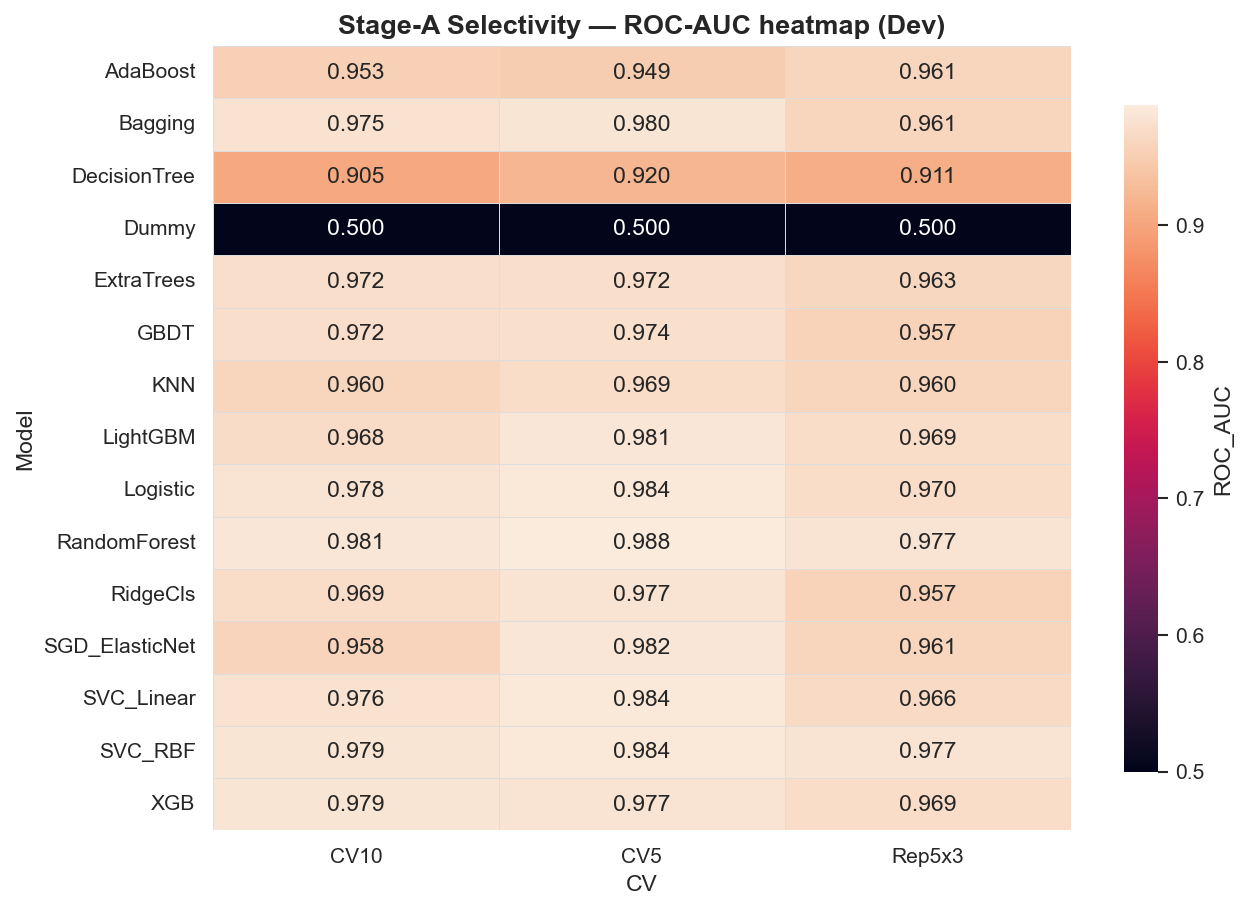

In [3]:
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, f1_score
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

try:
    from catboost import CatBoostClassifier
    _HAS_CATBOOST = True
except Exception:
    _HAS_CATBOOST = False

SPW = max(1.0, float((y_dev == 0).sum()) / max(1, int((y_dev == 1).sum())))
NEED_SCALER = {"Logistic","RidgeCls","SGD_ElasticNet","SVC_Linear","SVC_RBF","KNN"}

MODELS = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic": LogisticRegression(solver="liblinear", class_weight="balanced", random_state=SEED),
    "RidgeCls": RidgeClassifier(class_weight="balanced"),
    "SGD_ElasticNet": SGDClassifier(loss="log_loss", penalty="elasticnet", alpha=1e-3, l1_ratio=0.5,
                                    class_weight="balanced", random_state=SEED, max_iter=2000, tol=1e-3),
    "SVC_Linear": SVC(kernel="linear", C=1.0, probability=True, class_weight="balanced", random_state=SEED),
    "SVC_RBF": SVC(kernel="rbf", C=10.0, gamma="scale", probability=True, class_weight="balanced", random_state=SEED),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DecisionTree": DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=SEED, n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=400, class_weight="balanced", random_state=SEED, n_jobs=-1),
    "Bagging": BaggingClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(random_state=SEED),
    "GBDT": GradientBoostingClassifier(random_state=SEED),
    "XGB": XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=SEED, n_jobs=-1, scale_pos_weight=SPW
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        class_weight="balanced", random_state=SEED, n_jobs=-1
    ),
}
if _HAS_CATBOOST:
    MODELS["CatBoost"] = CatBoostClassifier(verbose=False, random_state=SEED)

def make_pipeline_safe(name, est):
    if name in NEED_SCALER:
        return Pipeline([("scaler", StandardScaler()), ("mdl", est)])
    return Pipeline([("mdl", est)])

SCORES = {
    "ACC": "accuracy",
    "BAL_ACC": "balanced_accuracy",
    "F1": make_scorer(f1_score, average="binary"),
    "ROC_AUC": "roc_auc",
    "PR_AUC": "average_precision",
}
CV_SCHEMES = {
    "CV5": StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    "CV10": StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED),
    "Rep5x3": RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED),
}

res_rows = []
for mdl_name, est in MODELS.items():
    pipe = make_pipeline_safe(mdl_name, est)
    for cv_name, cv in CV_SCHEMES.items():
        cv_res = cross_validate(pipe, X_dev, y_dev, cv=cv, scoring=SCORES, n_jobs=-1, return_train_score=False)
        res_rows.append({
            "Model": mdl_name, "CV": cv_name,
            **{f"{k}_mean": float(np.mean(v)) for k,v in cv_res.items() if k.startswith("test_") for k2 in [k.replace("test_","")]},
            **{f"{k}_std": float(np.std(v, ddof=1)) for k,v in cv_res.items() if k.startswith("test_") for k2 in [k.replace("test_","")]},
        })
# fix keys
rows_fixed=[]
for r in res_rows:
    row={"Model":r["Model"],"CV":r["CV"]}
    for k,v in list(r.items()):
        if k in {"Model","CV"}: continue
        # k like ACC_mean already due to comprehension? no, fix below
        row[k]=v
    rows_fixed.append(row)
coarse_df = pd.DataFrame(rows_fixed)
# rename any malformed keys
coarse_df.columns=[c.replace("test_","") for c in coarse_df.columns]
save_df(coarse_df.round(6), TAB_DIR/"coarse_cv_results.csv")

# leaderboard
lb = (coarse_df.groupby("Model")
      .agg(ROC_AUC_mean=("ROC_AUC_mean","mean"),
           PR_AUC_mean=("PR_AUC_mean","mean"),
           F1_mean=("F1_mean","mean"),
           BAL_ACC_mean=("BAL_ACC_mean","mean"),
           ACC_mean=("ACC_mean","mean"))
      .sort_values(["ROC_AUC_mean","PR_AUC_mean","F1_mean"], ascending=False)
      .reset_index())
display(lb.head(10))
save_df(lb.round(6), TAB_DIR/"coarse_leaderboard.csv")
top3 = lb["Model"].head(3).tolist()
print("Top-3 coarse models:", top3)

# heatmap
mat = coarse_df.pivot(index="Model", columns="CV", values="ROC_AUC_mean")
fig, ax = plt.subplots(figsize=(8.8, 6.2))
sns.heatmap(mat.round(3), annot=True, fmt=".3f", cmap=sns.color_palette("rocket", as_cmap=True),
            linewidths=.4, linecolor="#dddddd", cbar_kws={"shrink":0.85, "label":"ROC_AUC"}, ax=ax)
ax.set_title("Stage-A Selectivity — ROC-AUC heatmap (Dev)")
save_fig(fig, FIG_DIR/"coarse_roc_auc_heatmap.png")

Loaded tuned model: Pipeline
Threshold: 0.8699999999999999
scikit-learn version: 1.5.2
Using fitted feature order from: root (Pipeline)
Compatibility patch applied: {'cal__ensemble': True}


,CV,ROC_AUC,PR_AUC,F1,BAL_ACC,ACC,Threshold
0,CV5,0.9773,0.9767,0.8545,0.8730,0.9059,0.87
1,CV10,0.9758,0.9728,0.8750,0.8889,0.9176,0.87
2,Rep5x3,0.9576,0.9641,0.8750,0.8889,0.9176,0.87


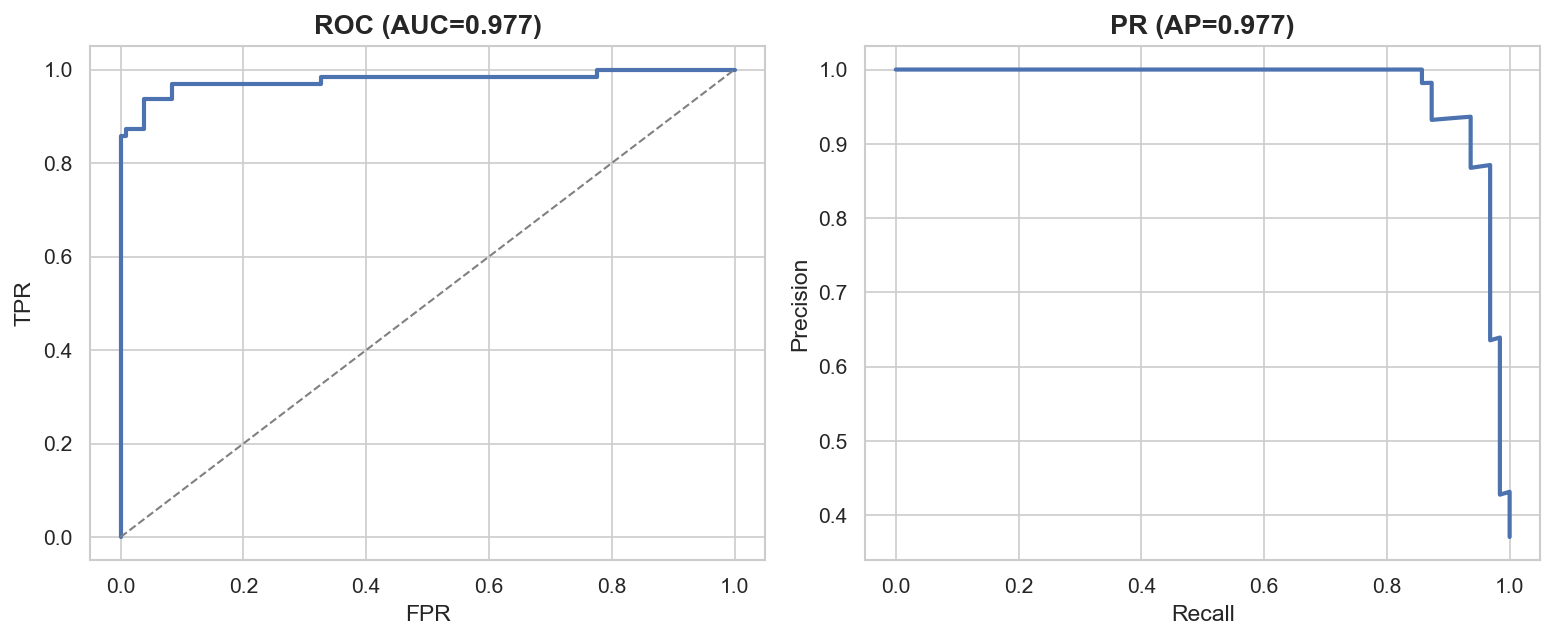

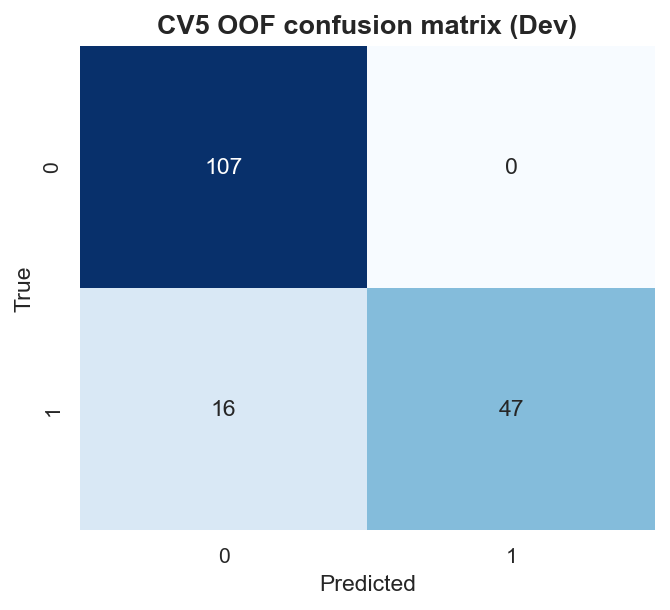

In [4]:
import joblib
import sklearn
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    balanced_accuracy_score, accuracy_score,
    precision_recall_curve, roc_curve, confusion_matrix
)

tuned_model = joblib.load(MODEL_FILE)
thr = float(meta.get("threshold", 0.5))

print("Loaded tuned model:", type(tuned_model).__name__)
print("Threshold:", thr)
print("scikit-learn version:", sklearn.__version__)

def get_scores(est, X):
    if hasattr(est, "predict_proba"):
        return est.predict_proba(X)[:, 1]
    if hasattr(est, "decision_function"):
        z = est.decision_function(X)
        z = z[:, 1] if getattr(z, "ndim", 1) > 1 else z
        return 1.0 / (1.0 + np.exp(-z))
    return est.predict(X).astype(float)

def metrics_binary(y_true, p_score, thr=0.5):
    y_true = np.asarray(y_true).astype(int)
    p_score = np.asarray(p_score).astype(float)
    y_pred = (p_score >= thr).astype(int)
    return {
        "ROC_AUC": roc_auc_score(y_true, p_score),
        "PR_AUC": average_precision_score(y_true, p_score),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "BAL_ACC": balanced_accuracy_score(y_true, y_pred),
        "ACC": accuracy_score(y_true, y_pred),
    }

def make_refit_compatible_template(est):
    """
    Compatibility patch for models saved with
    CalibratedClassifierCV(ensemble='auto').

    In scikit-learn, 'auto' was added in v1.6.
    For older versions, the equivalent behavior is:
    - False only when the estimator is a FrozenEstimator
    - True otherwise

    In this public module the tuned model is a Pipeline, not a FrozenEstimator,
    so 'auto' should be treated as True for refitting / OOF.
    """
    tpl = clone(est)
    params = tpl.get_params(deep=True)
    patch = {}

    for k, v in params.items():
        if (k == "ensemble" or k.endswith("__ensemble")) and isinstance(v, str) and v.lower() == "auto":
            patch[k] = True

    if patch:
        tpl.set_params(**patch)
        print("Compatibility patch applied:", patch)

    return tpl



def find_fitted_feature_order(est):
    """
    Recursively find the feature_names_in_ stored in the fitted public model
    (Pipeline / CalibratedClassifierCV / underlying estimator).
    """
    seen = set()
    queue = [("root", est)]
    while queue:
        node_name, obj = queue.pop(0)
        if obj is None or id(obj) in seen:
            continue
        seen.add(id(obj))

        if hasattr(obj, "feature_names_in_"):
            feats = [str(x) for x in getattr(obj, "feature_names_in_")]
            if len(feats) > 0:
                return feats, node_name, obj.__class__.__name__

        if hasattr(obj, "steps"):  # Pipeline-like
            try:
                for step_name, step_obj in obj.steps[::-1]:
                    queue.append((f"{node_name}.steps['{step_name}']", step_obj))
            except Exception:
                pass

        for attr in ("estimator_", "estimator", "base_estimator", "classifier", "final_estimator"):
            if hasattr(obj, attr):
                sub = getattr(obj, attr)
                if sub is not None:
                    queue.append((f"{node_name}.{attr}", sub))

        if hasattr(obj, "calibrated_classifiers_"):
            try:
                for i, sub in enumerate(getattr(obj, "calibrated_classifiers_")):
                    queue.append((f"{node_name}.calibrated_classifiers_[{i}]", sub))
            except Exception:
                pass

    return None, None, None

def align_X_columns(X, expected_cols, name="X"):
    expected_cols = list(expected_cols)
    missing = [c for c in expected_cols if c not in X.columns]
    extra = [c for c in X.columns if c not in expected_cols]
    if missing:
        raise ValueError(f"{name} is missing model features: {missing}")
    X2 = X.loc[:, expected_cols].copy()
    if extra:
        print(f"{name}: ignoring {len(extra)} extra columns not used by the model.")
    return X2


model_feats, feat_source, feat_owner = find_fitted_feature_order(tuned_model)
if model_feats is None:
    model_feats = list(final_feats)
    print('No fitted feature order found inside joblib; using selectivity_features.json order.')
else:
    print(f'Using fitted feature order from: {feat_source} ({feat_owner})')
    if list(model_feats) != list(final_feats):
        mismatch_n = sum(a != b for a, b in zip(list(final_feats), list(model_feats)))
        print(f'Feature-order mismatch detected between joblib and JSON: {mismatch_n} positions differ. Dev/Lockbox matrices will be reordered to the fitted-model order.')

feature_order_check = pd.DataFrame({
    'position': np.arange(1, len(model_feats) + 1),
    'model_feature': model_feats,
    'json_feature': list(final_feats)[:len(model_feats)],
})
save_df(feature_order_check, TAB_DIR / 'feature_order_check.csv')

final_feats = list(model_feats)
X_dev = align_X_columns(X_dev, final_feats, name='X_dev')
X_lock = align_X_columns(X_lock, final_feats, name='X_lock')

tuned_template = make_refit_compatible_template(tuned_model)

CV_SCHEMES = {
    "CV5": StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    "CV10": StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED),
    "Rep5x3": RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED),
}

rows = []
stored = {}

for cv_name, cv in CV_SCHEMES.items():
    oof = np.zeros(len(X_dev), dtype=float)
    for tr, va in cv.split(X_dev, y_dev):
        est = clone(tuned_template).fit(X_dev.iloc[tr], y_dev[tr])
        oof[va] = get_scores(est, X_dev.iloc[va])

    m = metrics_binary(y_dev, oof, thr)
    rows.append({"CV": cv_name, **m, "Threshold": thr})
    stored[cv_name] = oof

oof_df = pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False)
display(oof_df.round(4))
save_df(oof_df.round(6), TAB_DIR / "tuned_oof_dev_summary.csv")

# Use CV5 OOF as the public reference plot
oof_score = stored["CV5"]

fpr, tpr, _ = roc_curve(y_dev, oof_score)
prec, rec, _ = precision_recall_curve(y_dev, oof_score)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))

axes[0].plot(fpr, tpr, lw=2)
axes[0].plot([0, 1], [0, 1], "--", color="grey", lw=1)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title(f"ROC (AUC={roc_auc_score(y_dev, oof_score):.3f})")

axes[1].plot(rec, prec, lw=2)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"PR (AP={average_precision_score(y_dev, oof_score):.3f})")

save_fig(fig, FIG_DIR / "tuned_oof_dev_curves.png")

cm = confusion_matrix(y_dev, (oof_score >= thr).astype(int))
fig, ax = plt.subplots(figsize=(4.6, 4.2))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("CV5 OOF confusion matrix (Dev)")
save_fig(fig, FIG_DIR / "tuned_oof_dev_confusion.png")

SHAP base model: RandomForestClassifier


,feature,mean_abs_shap
0,EE_B_p,0.096266
1,SpMax2_Bh_m,0.067888
2,Vatomic,0.059888
3,EM,0.051749
4,X4v,0.026697
5,ATSC1p,0.020898
6,SpMin1_Bh_s,0.019104
7,GATS2p,0.015492
8,ATSC1e,0.015286
9,Mp,0.012003


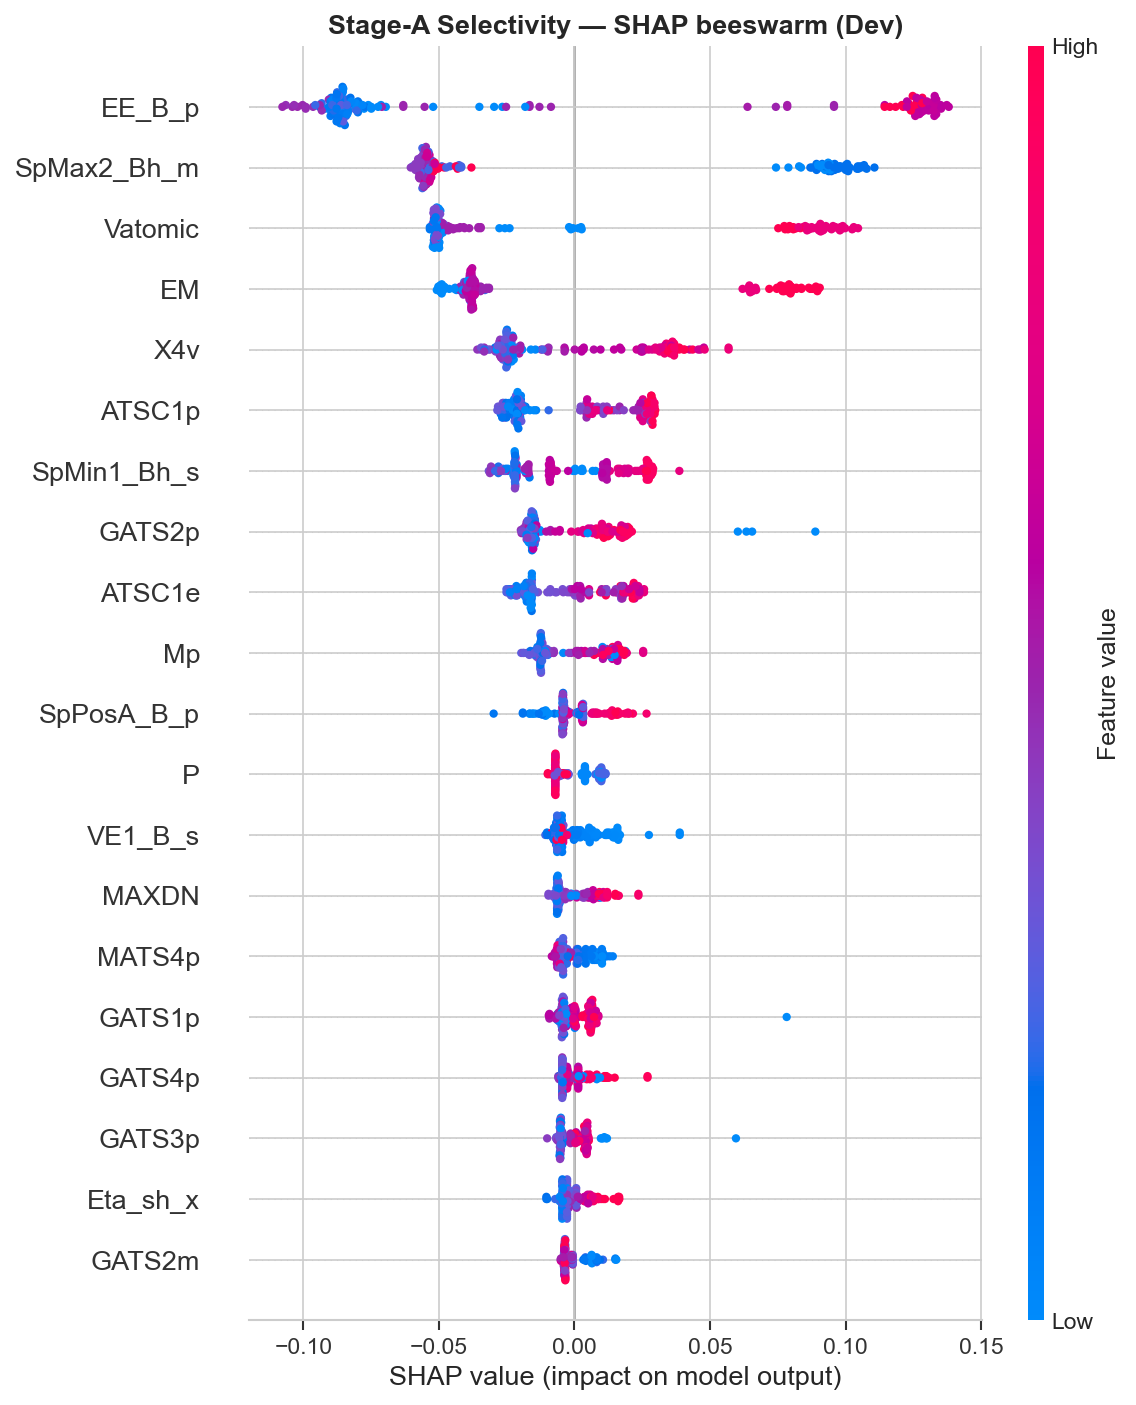

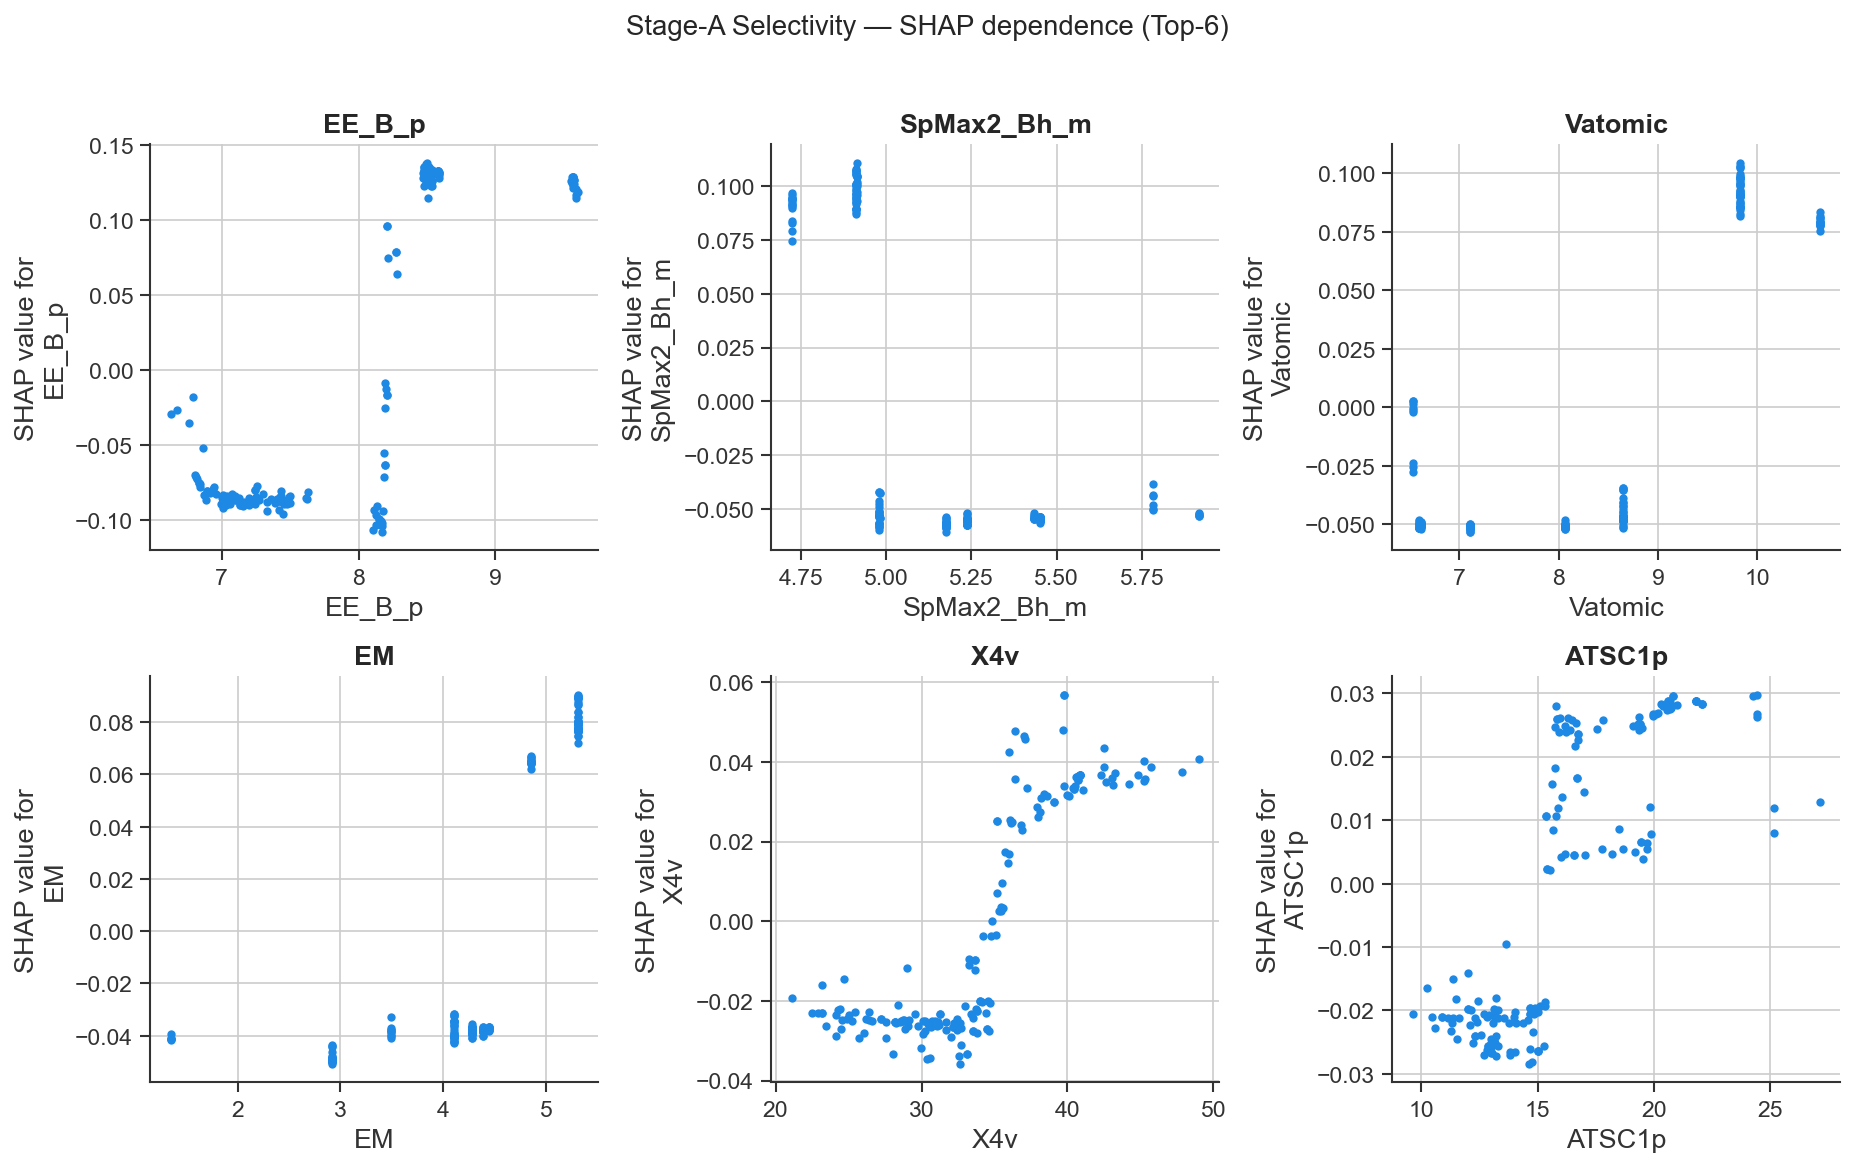

In [5]:
import shap
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

def unwrap_for_tree(obj):
    # stop at tree ensemble rather than drilling into its base decision tree
    tree_ensemble_names = {"RandomForestClassifier","ExtraTreesClassifier","XGBClassifier","LGBMClassifier","CatBoostClassifier"}
    seen = set()
    while True:
        if id(obj) in seen:
            break
        seen.add(id(obj))
        cls_name = obj.__class__.__name__
        if cls_name in tree_ensemble_names:
            return obj
        if isinstance(obj, Pipeline):
            obj = obj.steps[-1][1]
            continue
        if isinstance(obj, CalibratedClassifierCV):
            if hasattr(obj, "estimator") and obj.estimator is not None:
                obj = obj.estimator
                continue
            if hasattr(obj, "base_estimator") and obj.base_estimator is not None:
                obj = obj.base_estimator
                continue
        advanced = False
        for attr in ("classifier","final_estimator"):
            if hasattr(obj, attr) and getattr(obj, attr) is not None:
                obj = getattr(obj, attr); advanced=True; break
        if not advanced:
            return obj

base_template = unwrap_for_tree(tuned_model)
from sklearn.base import clone
base_model_for_shap = clone(base_template).fit(X_dev, y_dev)
print("SHAP base model:", base_model_for_shap.__class__.__name__)

X_shap = X_dev.copy()
explainer = shap.TreeExplainer(
    model=base_model_for_shap,
    data=X_shap,
    feature_names=final_feats,
    model_output="probability",
    feature_perturbation="interventional",
)
shap_values_raw = explainer.shap_values(X_shap, check_additivity=False)

if isinstance(shap_values_raw, list):
    shap_values = np.asarray(shap_values_raw[1] if len(shap_values_raw) > 1 else shap_values_raw[0], dtype=float)
else:
    arr = np.asarray(shap_values_raw)
    if arr.ndim == 3 and arr.shape[-1] >= 2:
        shap_values = np.asarray(arr[..., 1], dtype=float)
    else:
        shap_values = np.asarray(arr, dtype=float)

mean_abs = np.abs(shap_values).mean(axis=0)
shap_imp = pd.DataFrame({"feature": final_feats, "mean_abs_shap": mean_abs}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
display(shap_imp.head(15))
save_df(shap_imp, TAB_DIR / "shap_importance_dev.csv")
np.save(TAB_DIR / "shap_values_dev.npy", shap_values)

plt.figure(figsize=(8.0, 6.2))
shap.summary_plot(shap_values, X_shap, feature_names=final_feats, show=False, max_display=20)
plt.title("Stage-A Selectivity — SHAP beeswarm (Dev)")
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_beeswarm_dev.png", bbox_inches="tight")
plt.show()

top_dep = shap_imp["feature"].head(6).tolist()
ncols = 3
nrows = int(np.ceil(len(top_dep) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12.5, 3.8 * nrows))
axes = np.array(axes).reshape(-1)
for ax, feat in zip(axes, top_dep):
    shap.dependence_plot(feat, shap_values, X_shap, interaction_index=None, ax=ax, show=False)
    ax.set_title(feat)
for ax in axes[len(top_dep):]:
    ax.axis("off")
fig.suptitle("Stage-A Selectivity — SHAP dependence (Top-6)", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_dependence_top6_dev.png", bbox_inches="tight")
plt.show()

,ROC_AUC,PR_AUC,F1,BAL_ACC,ACC
0,0.9785,0.9679,0.9524,0.9545,0.9667


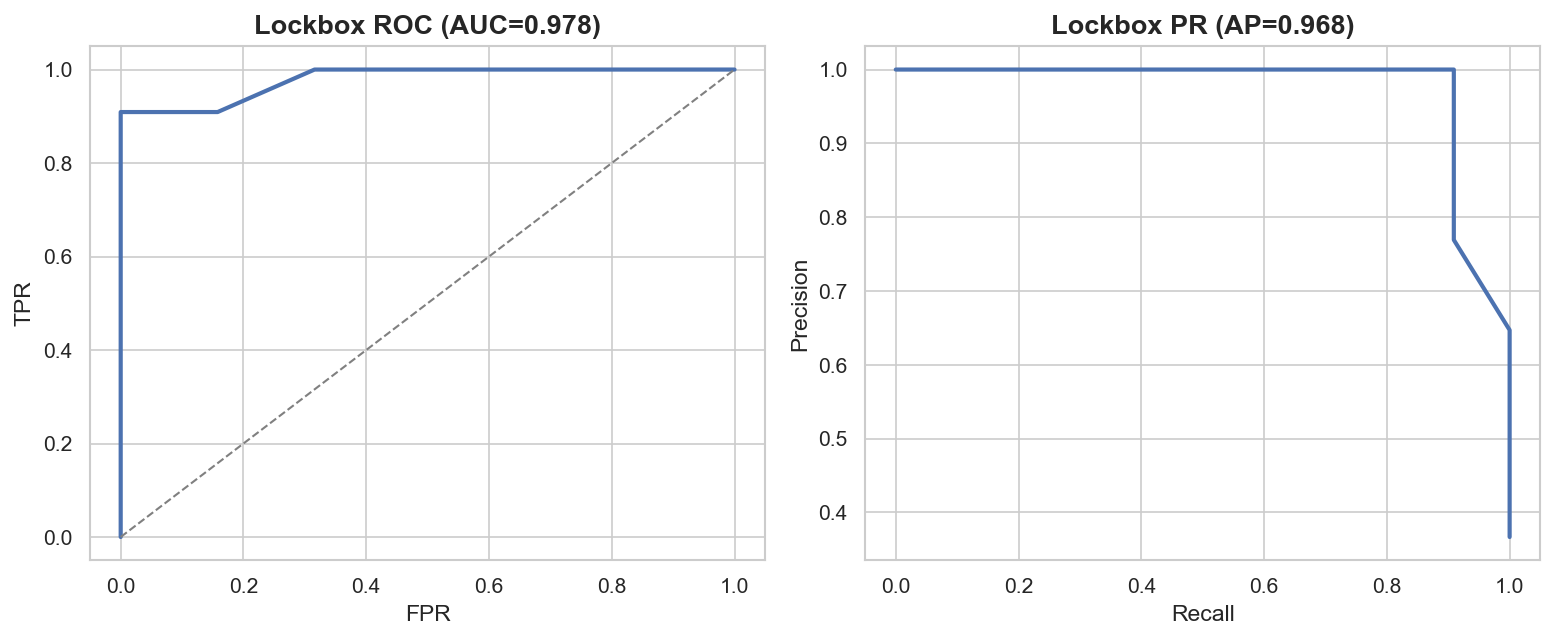

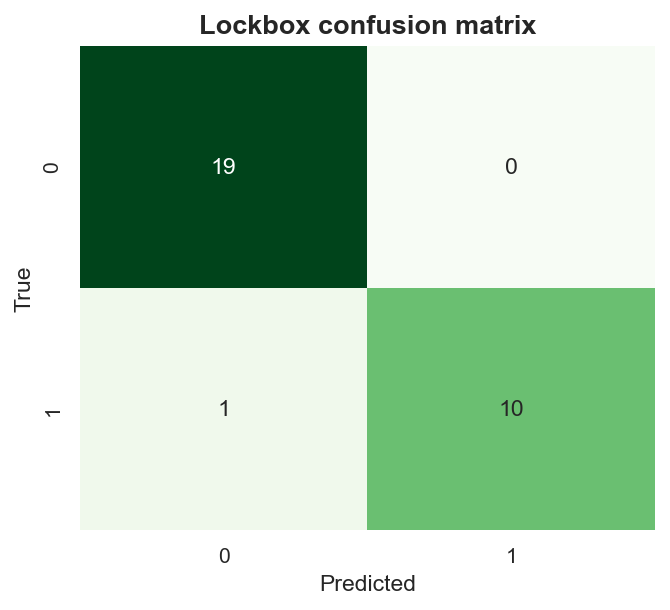

In [6]:
p_lock = get_scores(tuned_model, X_lock)
lock_metrics = pd.DataFrame([metrics_binary(y_lock, p_lock, thr)])
display(lock_metrics.round(4))
save_df(lock_metrics.round(6), TAB_DIR / "lockbox_metrics.csv")

fpr, tpr, _ = roc_curve(y_lock, p_lock)
prec, rec, _ = precision_recall_curve(y_lock, p_lock)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
axes[0].plot(fpr, tpr, lw=2)
axes[0].plot([0, 1], [0, 1], '--', color='grey', lw=1)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title(f"Lockbox ROC (AUC={roc_auc_score(y_lock,p_lock):.3f})")
axes[1].plot(rec, prec, lw=2)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title(f"Lockbox PR (AP={average_precision_score(y_lock,p_lock):.3f})")
save_fig(fig, FIG_DIR / "lockbox_curves.png")

cm = confusion_matrix(y_lock, (p_lock >= thr).astype(int))
fig, ax = plt.subplots(figsize=(4.6,4.2))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Lockbox confusion matrix")
save_fig(fig, FIG_DIR / "lockbox_confusion.png")